Farmers market Data

What time and day is the best day to go find a farmers market.

In [ ]:
#import libraries

import urllib.request
import json
import pymongo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt



First we need to add the URL for our data  and prepare it for to link to MonogDB.

In [ ]:
#call url and read data
Market="https://data.montgomerycountymd.gov/api/views/5bba-wcx9/rows.json?accessType=DOWNLOAD"
open=urllib.request.urlopen(Market)
read=open.read().decode('utf-8')

In [11]:
#convert the Json to python readable
converted=json.loads(read)
Title=converted['meta']['view']['name']
print(Title)

Farmers Markets and Farm Stands  2026


In [ ]:
#find all keys in the json file
def get_all_keys(json_object, keys_list):
    if isinstance(json_object, dict):
        keys_list.extend(json_object.keys())
        for value in json_object.values():
            get_all_keys(value, keys_list)
    elif isinstance(json_object, list):
        for item in json_object:
            get_all_keys(item, keys_list)
    return keys_list

keys=[]
keys=get_all_keys(converted,keys)
print(keys)

['meta', 'data', 'view', 'id', 'name', 'assetType', 'averageRating', 'category', 'createdAt', 'description', 'diciBackend', 'displayType', 'downloadCount', 'hideFromCatalog', 'hideFromDataJson', 'locked', 'newBackend', 'numberOfComments', 'oid', 'provenance', 'publicationAppendEnabled', 'publicationDate', 'publicationGroup', 'publicationStage', 'rowsUpdatedAt', 'rowsUpdatedBy', 'tableId', 'totalTimesRated', 'viewCount', 'viewLastModified', 'viewType', 'approvals', 'clientContext', 'columns', 'grants', 'metadata', 'owner', 'query', 'rights', 'tableAuthor', 'tags', 'flags', 'reviewedAt', 'reviewedAutomatically', 'state', 'submissionId', 'submissionObject', 'submissionOutcome', 'submittedAt', 'targetAudience', 'workflowId', 'reviewer', 'submissionDetails', 'submissionOutcomeApplication', 'submitter', 'id', 'displayName', 'permissionType', 'endedAt', 'failureCount', 'startedAt', 'status', 'id', 'displayName', 'clientContextVariables', 'inheritedVariables', 'id', 'name', 'dataTypeName', 'fi

In [30]:
# Extract the records (list of lists) from 'converted'
records = converted['data']

# Extract column names from the meta information
columns = [col['name'] for col in data['meta']['view']['columns']]

# Create the DataFrame
df = pd.DataFrame(records, columns=columns)
# Print the DataFrame
print(df)

                   sid                                    id  position  \
0   row-xy5m.sybt~i52x  00000000-0000-0000-B7C3-6B6C2CD4B470         0   
1   row-bpt3~zk82_dt8f  00000000-0000-0000-497B-EC965C556598         0   
2   row-kn74-jwns~bmwt  00000000-0000-0000-6E02-C296CF397456         0   
3   row-t3wz-wvh9-3wca  00000000-0000-0000-9933-681585CA96F7         0   
4   row-kiru-64cj_qxr5  00000000-0000-0000-42B4-98E845BDFB09         0   
5   row-857a-tyd4-nrh3  00000000-0000-0000-04D7-376414D881D2         0   
6   row-cwbr.zsss_shwt  00000000-0000-0000-D062-E6ECA198E02A         0   
7   row-uiga~uarr~i2p3  00000000-0000-0000-39D8-DA94705014AE         0   
8   row-s8cu-g649.bm64  00000000-0000-0000-59B3-D9F8C1CD1DC4         0   
9   row-dgfv.nfm9~v52v  00000000-0000-0000-F4DC-A791EDE5B1B7         0   
10  row-cnf3_ye6z~2dez  00000000-0000-0000-45E9-6E34F0E8B938         0   
11  row-4ajy-t7rt_7cbg  00000000-0000-0000-4B62-32395C195570         0   
12  row-zjqt_umgh_63sg  00000000-0000-

Now that we have ensured the Json is in a usuable format we can begin to link it to MongoDB before analysis

In [32]:
try:
    client = pymongo.MongoClient('localhost', 27017)
    print("Connected successfully!!!")
except pymongo.errors.ConnectionFailure as e:
    print("Could not connect to MongoDB: %s" % e)
else:
    # create database market
    db = client.farmermarket
    # create markets collection
    markets = db.market
    # convert records to list of dictionaries using columns as keys
    data_to_insert = [dict(zip(columns, record)) for record in records]
    # insert the data
    markets.insert_many(data_to_insert)
    print("Added", len(data_to_insert), "Farmers markets added to database")
    # close the database connection
    client.close()


Connected successfully!!!
Added 28 Farmers markets added to database


What date and time are the most markets open


C:\Users\David Eister\AppData\Local\Temp\ipykernel_18512\1441272740.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_counts.index, y=day_counts.values, palette='viridis')


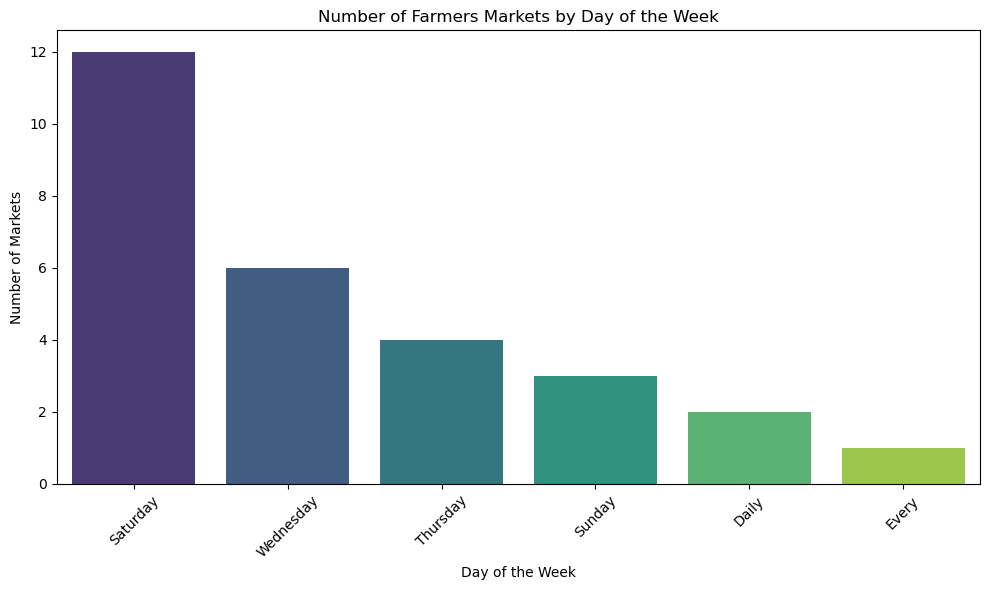

In [ ]:
# Reconnect to MongoDB to retrieve data
client = pymongo.MongoClient('localhost', 27017)
db = client.farmermarket
markets = db.market
# Retrieve all market records
market_data = list(markets.find())
# Create a DataFrame from the retrieved data
df = pd.DataFrame(market_data)
# Extract the day of the week from the 'Days' column
df['DayOfWeek'] = df['Days'].apply(lambda x: x.split()[0] if isinstance(x, str) else None)
# Count the number of markets for each day of the week
day_counts = df['DayOfWeek'].value_counts()
# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=day_counts.index, y=day_counts.values, palette='viridis')
plt.title('Number of Farmers Markets by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Markets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\David Eister\AppData\Local\Temp\ipykernel_18512\750271492.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hour_counts.index, y=hour_counts.values, palette='viridis')


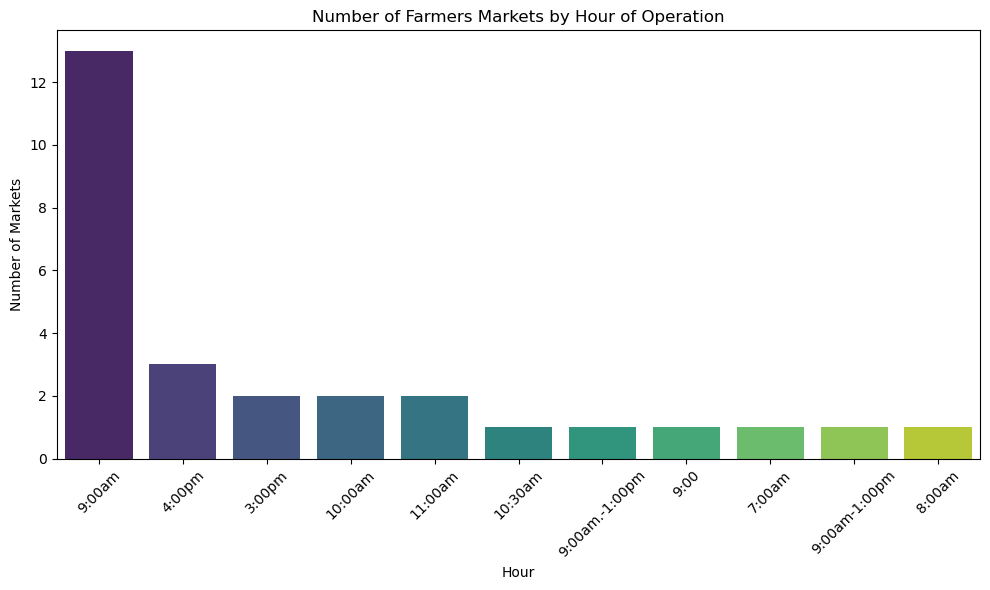

In [44]:
df['Hour'] = df['Times Open Season 1'].apply(lambda x: x.split()[0] if isinstance(x, str) else None)
hour_counts = df['Hour'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=hour_counts.index, y=hour_counts.values, palette='viridis')
plt.title('Number of Farmers Markets by Hour of Operation')
plt.xlabel('Hour')
plt.ylabel('Number of Markets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Looking at the Data it appears the best time to find a farmers market to go to in Montogmer County in Maryland